# POS Hypothesis Explorer

## How to use

1. Make sure your experiment JSON outputs exist under `resources/results/`.
2. Adjust `PROJECT_ROOT` below if needed.
3. Run all cells from top to bottom.
4. Use `SELECTION_METRIC` near the top to choose how “best” is defined.

Recommended metrics:
- `f1` for overall model quality
- `token_accuracy` for straightforward token-level comparison
- `best_val_accuracy` to inspect validation performance


In [42]:
from pathlib import Path

# Adjust if needed
PROJECT_ROOT = Path("/home/dan-gavriluta/Coding/ml-project")
RESULTS_ROOT = PROJECT_ROOT / "resources" / "results"
MODELS_ROOT = PROJECT_ROOT / "resources" / "models"

SELECTION_METRIC = "f1"  # options: f1, token_accuracy, precision, recall, best_val_accuracy

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)
print("Exists:", RESULTS_ROOT.exists())


PROJECT_ROOT: /home/dan-gavriluta/Coding/ml-project
RESULTS_ROOT: /home/dan-gavriluta/Coding/ml-project/resources/results
Exists: True


In [43]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)
sns.set_theme(style="whitegrid")

def load_all_result_files(results_root: Path):
    return sorted(results_root.rglob("training_results.json"))

def load_all_runs(results_root: Path):
    files = load_all_result_files(results_root)
    runs = []
    for fp in files:
        with fp.open("r", encoding="utf-8") as f:
            payload = json.load(f)
        if isinstance(payload, dict):
            payload = [payload]
        for run in payload:
            run["_results_file"] = str(fp)
            run["_results_folder"] = str(fp.parent)
            runs.append(run)
    return files, runs

def flatten_run(run):
    row = {
        "name": run.get("name"),
        "model_type": run.get("model_type"),
        "best_val_accuracy": run.get("best_val_accuracy"),
        "best_val_loss": run.get("best_val_loss"),
        "train_time_sec": run.get("train_time_sec"),
        "num_params": run.get("num_params"),
        "epochs_ran": run.get("epochs_ran"),
        "model_path": run.get("model_path"),
        "model_saved": run.get("model_saved"),
        "_results_file": run.get("_results_file"),
        "_results_folder": run.get("_results_folder"),
    }

    tm = run.get("test_metrics", {})
    for k, v in tm.items():
        row[k] = v

    cfg = run.get("config", {})
    for k, v in cfg.items():
        row[f"cfg_{k}"] = v

    dm = run.get("dataset_meta", {})
    row["group"] = cfg.get("group")
    row["hypothesis"] = cfg.get("hypothesis")
    row["sentences"] = dm.get("sentences", cfg.get("sentences"))
    row["maxlen"] = dm.get("maxlen", cfg.get("maxlen"))
    row["split_seed"] = dm.get("split_seed", cfg.get("split_seed"))
    row["run_seed"] = dm.get("seed", cfg.get("seed"))
    row["vocab_size"] = dm.get("vocab_size", cfg.get("vocab_size"))
    row["num_tags"] = dm.get("num_tags", cfg.get("num_tags"))

    return row

def runs_to_df(runs):
    if not runs:
        return pd.DataFrame()
    df = pd.DataFrame([flatten_run(r) for r in runs])

    numeric_cols = [
        "best_val_accuracy", "best_val_loss", "train_time_sec", "num_params", "epochs_ran",
        "token_accuracy", "precision", "recall", "f1",
        "sentences", "maxlen", "split_seed", "run_seed", "vocab_size", "num_tags",
        "cfg_lr", "cfg_dropout", "cfg_batch_size", "cfg_embed_dim", "cfg_ff_dim",
        "cfg_num_layers", "cfg_num_heads", "cfg_lstm_units", "cfg_lstm_layers",
        "cfg_lr_warmup_steps",
    ]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def get_hypothesis(df, hypothesis_name):
    return df[df["hypothesis"] == hypothesis_name].copy()

def show_top(df, metric="f1", n=10):
    cols = [
        "name", "group", "model_type", metric,
        "token_accuracy", "best_val_accuracy", "train_time_sec",
        "num_params", "sentences", "maxlen", "split_seed", "run_seed"
    ]
    cols = [c for c in cols if c in df.columns]
    return df.sort_values(metric, ascending=False)[cols].head(n).reset_index(drop=True)

def plot_bar(df_group, metric="f1", title=None, hue="model_type", figsize=(12, 5)):
    if df_group.empty:
        print("No rows for this plot.")
        return
    order = df_group.sort_values(metric, ascending=False)["name"]
    plt.figure(figsize=figsize)
    sns.barplot(data=df_group, x="name", y=metric, hue=hue, order=order)
    plt.xticks(rotation=35, ha="right")
    plt.title(title or f"{metric} by run")
    plt.tight_layout()
    plt.show()

def plot_line(df_group, x, y="f1", hue="model_type", marker="o", title=None, figsize=(10, 5)):
    if df_group.empty:
        print("No rows for this plot.")
        return
    plt.figure(figsize=figsize)
    sns.lineplot(data=df_group.sort_values([hue, x]), x=x, y=y, hue=hue, marker=marker)
    plt.title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

def plot_histories(runs, hypothesis_name, metric="val_accuracy", figsize=(10, 5)):
    plt.figure(figsize=figsize)
    used = False
    for run in runs:
        cfg = run.get("config", {})
        if cfg.get("hypothesis") != hypothesis_name:
            continue
        hist = run.get("history", {})
        vals = hist.get(metric, [])
        if vals:
            used = True
            plt.plot(range(1, len(vals) + 1), vals, label=run.get("name"))
    if not used:
        print("No history found for this hypothesis/metric.")
        return
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"{hypothesis_name}: {metric}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def annotate_scatter(df_group, x="train_time_sec", y="f1", figsize=(8, 5), title=None):
    if df_group.empty:
        print("No rows for this plot.")
        return
    plt.figure(figsize=figsize)
    sns.scatterplot(data=df_group, x=x, y=y, hue="model_type", s=80)
    for _, row in df_group.iterrows():
        plt.annotate(row["name"], (row[x], row[y]), fontsize=8)
    plt.title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

def grouped_summary(df_group, by, metric="f1"):
    if df_group.empty:
        return pd.DataFrame()
    return (
        df_group.groupby(by, dropna=False)[metric]
        .agg(["count", "mean", "std", "min", "max"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

def heatmap_split_seed_vs_run_seed(df_group, metric="f1", model_type=None, figsize=(6, 5)):
    temp = df_group.copy()
    if model_type is not None:
        temp = temp[temp["model_type"] == model_type]
    if temp.empty:
        print("No rows for this heatmap.")
        return
    pivot = temp.pivot_table(index="split_seed", columns="run_seed", values=metric, aggfunc="mean")
    plt.figure(figsize=figsize)
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis")
    title = f"{metric} heatmap"
    if model_type:
        title += f" — {model_type}"
    plt.title(title)
    plt.tight_layout()
    plt.show()

def practical_score(df, metric="f1", time_penalty=0.001):
    out = df.copy()
    out["practical_score"] = out[metric] - time_penalty * out["train_time_sec"].fillna(0)
    return out

files, runs = load_all_runs(RESULTS_ROOT)
df = runs_to_df(runs)

print(f"Found {len(files)} result file(s)")
print(f"Loaded {len(runs)} run(s)")

Found 7 result file(s)
Loaded 56 run(s)


In [44]:
import keras

def load_model_and_tags(model_path, models_root):
    """Load a saved model and extract tag information from the results."""
    if not model_path:
        return None, None
    
    full_path = models_root / model_path
    if not full_path.exists():
        return None, None
    
    try:
        model = keras.models.load_model(full_path)
        return model, None
    except Exception as e:
        print(f"Error loading model from {full_path}: {e}")
        return None, None

def get_tag_performance(df_subset, models_root):
    """Extract per-tag performance from test results if available."""
    tag_data = []
    
    for _, row in df_subset.iterrows():
        results_folder = row.get("_results_folder")
        if not results_folder:
            continue
            
        results_path = Path(results_folder) / "training_results.json"
        if not results_path.exists():
            continue
            
        with open(results_path, "r") as f:
            results = json.load(f)
            if isinstance(results, dict):
                results = [results]
            
            for result in results:
                if result.get("name") == row["name"]:
                    tag_metrics = result.get("test_metrics", {}).get("per_tag", {})
                    if tag_metrics:
                        for tag, metrics in tag_metrics.items():
                            tag_data.append({
                                "name": row["name"],
                                "model_type": row["model_type"],
                                "hypothesis": row["hypothesis"],
                                "tag": tag,
                                "f1": metrics.get("f1", 0),
                                "precision": metrics.get("precision", 0),
                                "recall": metrics.get("recall", 0),
                                "support": metrics.get("support", 0)
                            })
    
    return pd.DataFrame(tag_data) if tag_data else pd.DataFrame()

def plot_tag_performance(df_subset, models_root, metric="f1", top_n=15, figsize=(14, 6)):
    """Plot per-tag performance as bar charts."""
    tag_df = get_tag_performance(df_subset, models_root)
    
    if tag_df.empty:
        print("No per-tag performance data found in results.")
        return
    
    # Get top N tags by average support across all models
    tag_support = tag_df.groupby("tag")["support"].mean().sort_values(ascending=False)
    top_tags = tag_support.head(top_n).index.tolist()
    
    # Filter to top tags
    tag_df_filtered = tag_df[tag_df["tag"].isin(top_tags)]
    
    if tag_df_filtered.empty:
        print("No tag data after filtering.")
        return
    
    # Calculate average performance per tag and model type
    tag_summary = tag_df_filtered.groupby(["tag", "model_type"])[metric].mean().reset_index()
    
    plt.figure(figsize=figsize)
    
    # Sort tags by average performance
    tag_order = tag_df_filtered.groupby("tag")[metric].mean().sort_values(ascending=False).index
    
    sns.barplot(data=tag_summary, x="tag", y=metric, hue="model_type", order=tag_order)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Per-Tag {metric.upper()} Performance (Top {top_n} tags by frequency)")
    plt.ylabel(f"Average {metric.upper()}")
    plt.xlabel("POS Tag")
    plt.legend(title="Model Type")
    plt.tight_layout()
    plt.show()
    
    return tag_df_filtered

print("Tag analysis functions loaded.")

Tag analysis functions loaded.


In [45]:
if df.empty:
    print("No results found. Run experiments first.")
else:
    display(Markdown("### Discovered result files"))
    display(pd.DataFrame({"results_file": [str(f) for f in files]}))

    display(Markdown("### Overall top runs"))
    display(show_top(df, metric=SELECTION_METRIC, n=15))

    display(Markdown("### Run counts by group"))
    group_counts = df.groupby(["group", "model_type"]).size().reset_index(name="runs")
    display(group_counts.sort_values(["group", "model_type"]).reset_index(drop=True))


### Discovered result files

,results_file
0,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_1_high_lr_ud/training_results.json
1,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_1_low_lr_ud/training_results.json
2,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_1_medium_lr_ud/training_results.json
3,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_2_high_lr_ud/training_results.json
4,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_2_low_lr_ud/training_results.json
5,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_2_medium_lr_ud/training_results.json
6,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_3_fixed_lr_brown/training_results.json


### Overall top runs

,name,group,model_type,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params,sentences,maxlen,split_seed,run_seed
0,A_lstm_stronger_smax,A_baseline_family_comparison,lstm,0.953639,0.954689,0.955688,1154.073946,6686518,57340,30,42,42
1,A_lstm_stronger_s30000,A_baseline_family_comparison,lstm,0.937449,0.940275,0.939445,173.592195,5132552,30000,30,42,42
2,A_lstm_stronger_smax,A_baseline_family_comparison,lstm,0.923832,0.924360,0.925386,56.657320,2450707,12543,30,42,42
3,A_lstm_small_smax,A_baseline_family_comparison,lstm,0.922212,0.923105,0.922606,58.737242,597779,12543,30,42,42
4,A_lstm_stronger_s10000,A_baseline_family_comparison,lstm,0.921627,0.922145,0.921059,39.058113,2230419,10000,30,42,42
5,A_lstm_small_s10000,A_baseline_family_comparison,lstm,0.919217,0.920230,0.918094,37.813608,542707,10000,30,42,42
6,A_transformer_medium_smax,A_baseline_family_comparison,transformer,0.917934,0.919233,0.951862,42.531069,6799926,57340,30,42,42
7,A_lstm_stronger_s7000,A_baseline_family_comparison,lstm,0.916328,0.917241,0.918269,30.795024,1896083,7000,30,42,42
8,A_lstm_small_s7000,A_baseline_family_comparison,lstm,0.912580,0.913720,0.913766,27.256206,459123,7000,30,42,42
9,A_transformer_medium_s30000,A_baseline_family_comparison,transformer,0.909366,0.910855,0.943188,23.655699,5251848,30000,30,42,42


### Run counts by group

,group,model_type,runs
0,A_baseline_family_comparison,lstm,28
1,A_baseline_family_comparison,transformer,28


## Overall interpretation guide

Use these rules while reading the plots:

- **Higher `f1` / `token_accuracy` is better**
- **Lower `best_val_loss` is better**
- **Lower `train_time_sec` is better**
- If one family wins by only a tiny margin but is much slower, check the practical tradeoff
- For groups that vary data size or max length, compare trends, not just one isolated bar
- For robustness, prefer **mean performance + low variance** over one lucky best run


In [46]:
leaderboard_cols = [
    "name", "group", "model_type",
    "token_accuracy", "f1", "precision", "recall",
    "best_val_accuracy", "best_val_loss",
    "train_time_sec", "epochs_ran",
]

config_cols = [
    "name", "model_type",
    "num_params",
    "cfg_embed_dim", "cfg_num_heads", "cfg_ff_dim", "cfg_num_layers",
    "cfg_lstm_units", "cfg_lstm_layers", "cfg_dropout", "cfg_lr",
    "cfg_lr_warmup_steps", "cfg_batch_size",
]

meta_cols = [
    "name", "model_type",
    "sentences", "maxlen", "split_seed", "run_seed",
    "vocab_size", "num_tags",
    "predict_batch_size_used", "predict_device",
]

# Hypothesis 1 — Transformer vs LSTM with Learning Rate Impact

**Hypothesis**  
Transformers outperform LSTMs on POS tagging, especially with larger datasets and appropriate learning rates.

**Controlled factors**
- Two architectures: Transformer (medium) vs LSTM (stronger)
- Multiple data sizes: 2000, 5000, 7000, 10000, max sentences
- Three learning rates: 0.00001 (low), 0.0001 (medium), 0.001 (high)

**What to look for**
- Does Transformer consistently beat LSTM?
- How does performance scale with data size for each architecture?
- Which learning rate works best for each architecture?

In [47]:
# Filter data for Hypothesis 1
h1_data = get_hypothesis(df, "H1_learning_rate_impact")

if h1_data.empty:
    print("No H1 data found yet. Run experiments with hypothesis='H1_learning_rate_impact' in config.")
else:
    print(f"Found {len(h1_data)} runs for Hypothesis 1")
    display(Markdown("### Hypothesis 1 — All runs"))
    display_cols = [
        "name", "model_type", "sentences", "cfg_lr",
        "f1", "token_accuracy", "best_val_accuracy",
        "train_time_sec", "num_params"
    ]
    display_cols = [c for c in display_cols if c in h1_data.columns]
    display(h1_data[display_cols].sort_values(["sentences", "cfg_lr", "model_type"]).reset_index(drop=True))

Found 24 runs for Hypothesis 1


### Hypothesis 1 — All runs

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params
0,A_lstm_stronger_s5000,lstm,5000,0.00001,0.116445,0.218380,0.223406,31.730683,1490323
1,A_transformer_medium_s5000,transformer,5000,0.00001,0.575911,0.592352,0.818708,18.368261,1624595
2,A_lstm_stronger_s5000,lstm,5000,0.00010,0.707496,0.738262,0.745173,31.431642,1490323
3,A_transformer_medium_s5000,transformer,5000,0.00010,0.850054,0.850425,0.934625,17.783564,1624595
4,A_lstm_stronger_s5000,lstm,5000,0.00100,0.906864,0.907268,0.919126,26.360350,1490323
5,A_transformer_medium_s5000,transformer,5000,0.00100,0.852412,0.853468,0.939042,16.997399,1624595
6,A_lstm_stronger_s7000,lstm,7000,0.00001,0.114891,0.215163,0.223588,41.152371,1896083
7,A_transformer_medium_s7000,transformer,7000,0.00001,0.655500,0.668623,0.840655,13.185274,2030355
8,A_lstm_stronger_s7000,lstm,7000,0.00010,0.816609,0.832135,0.833313,40.961694,1896083
9,A_transformer_medium_s7000,transformer,7000,0.00010,0.853522,0.854585,0.930685,13.163425,2030355


### Interpretation

**Expected outcomes:**
1. **Learning rate preference**:
   - LSTM should perform best at higher LR (e.g., 1e-3)
   - Transformer should perform best at lower LR (e.g., 1e-4 or 5e-4)

2. **Data scaling**:
   - At low data (500-2000 sentences): LSTM and Transformer should be competitive
   - At high data (5000-12543 sentences): Transformer should pull ahead significantly
   - The gap should widen as data increases

3. **Combined effect**:
   - Transformer at low LR + high data should be the winning combination
   - LSTM's advantage (if any) should be limited to high LR + low data scenarios

### Visualization 3: Heatmap of LR × Data Size

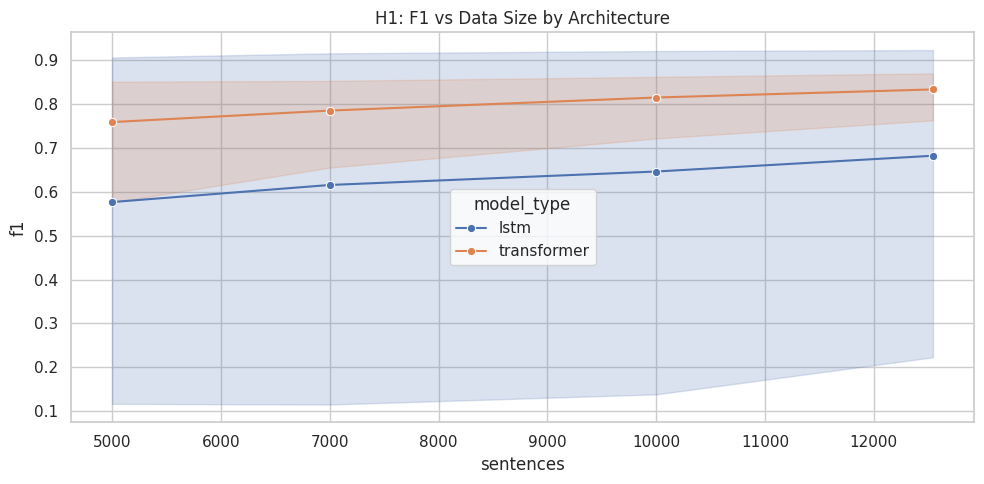

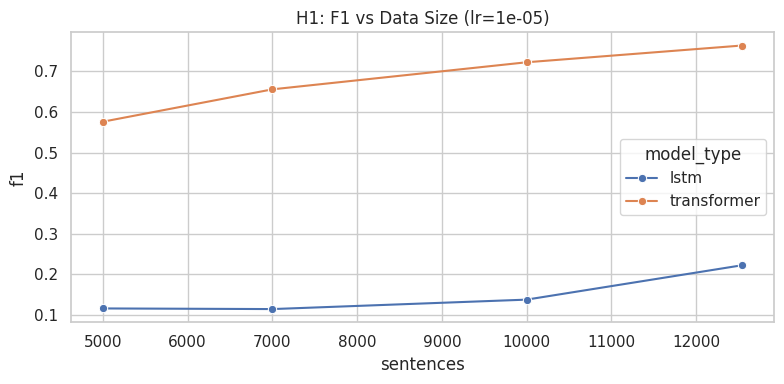

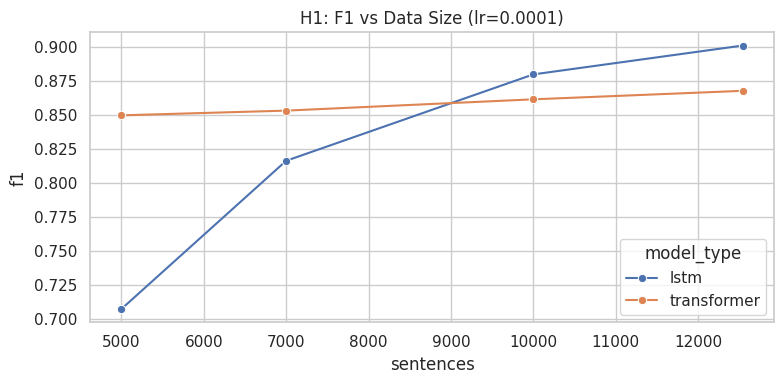

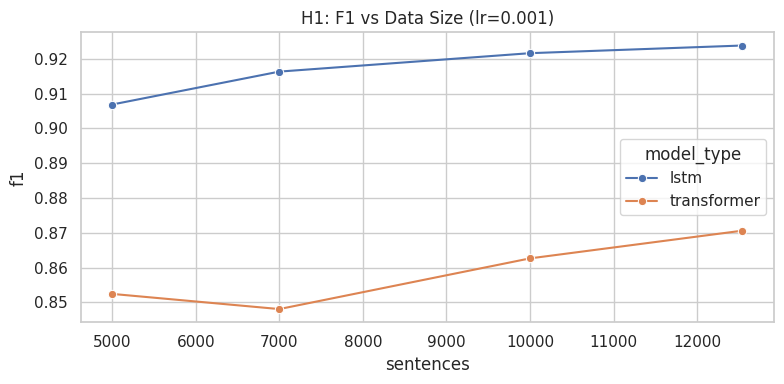

In [48]:
if not h1_data.empty:
    plot_line(
        h1_data,
        x="sentences",
        y=SELECTION_METRIC,
        hue="model_type",
        title=f"H1: {SELECTION_METRIC.upper()} vs Data Size by Architecture",
        figsize=(10, 5)
    )

    # Also show for each learning rate separately
    for lr in sorted(h1_data["cfg_lr"].unique()):
        subset = h1_data[h1_data["cfg_lr"] == lr]
        if len(subset) > 0:
            plot_line(
                subset,
                x="sentences",
                y=SELECTION_METRIC,
                hue="model_type",
                title=f"H1: {SELECTION_METRIC.upper()} vs Data Size (lr={lr})",
                figsize=(8, 4)
            )

### Final tables 

In [49]:
if not h1_data.empty:
    # Summary by model type and learning rate
    display(Markdown("#### By model type and learning rate"))
    lr_summary = grouped_summary(h1_data, by=["model_type", "cfg_lr"], metric=SELECTION_METRIC)
    display(lr_summary)

    # Summary by model type and sentence count
    display(Markdown("#### By model type and sentence count"))
    data_summary = grouped_summary(h1_data, by=["model_type", "sentences"], metric=SELECTION_METRIC)
    display(data_summary)

#### By model type and learning rate

,model_type,cfg_lr,count,mean,std,min,max
0,lstm,0.00100,4,0.917163,0.007554,0.906864,0.923832
1,transformer,0.00100,4,0.858420,0.010159,0.848049,0.870597
2,transformer,0.00010,4,0.858377,0.008151,0.850054,0.868098
3,lstm,0.00010,4,0.826429,0.087094,0.707496,0.901433
4,transformer,0.00001,4,0.679205,0.081947,0.575911,0.763323
5,lstm,0.00001,4,0.148032,0.050882,0.114891,0.222681


#### By model type and sentence count

,model_type,sentences,count,mean,std,min,max
0,transformer,12543,3,0.834006,0.061226,0.763323,0.870597
1,transformer,10000,3,0.815514,0.080914,0.722084,0.862623
2,transformer,7000,3,0.785691,0.112781,0.655500,0.853522
3,transformer,5000,3,0.759459,0.158962,0.575911,0.852412
4,lstm,12543,3,0.682649,0.398501,0.222681,0.923832
5,lstm,10000,3,0.646639,0.440885,0.138112,0.921627
6,lstm,7000,3,0.615943,0.436778,0.114891,0.916328
7,lstm,5000,3,0.576935,0.411066,0.116445,0.906864


In [50]:
display(Markdown("### Hypothesis 1 — Per-Tag Performance"))

if not h1_data.empty:
    # Plot tag performance for H1
    tag_df_h1 = plot_tag_performance(h1_data, MODELS_ROOT, metric=SELECTION_METRIC, top_n=15)
    
    # Show tag performance for best models from each architecture
    if tag_df_h1 is not None and not tag_df_h1.empty:
        display(Markdown("#### Tag-level comparison"))
        for mt in h1_data["model_type"].unique():
            best_run = h1_data[h1_data["model_type"] == mt].nlargest(1, SELECTION_METRIC)
            if not best_run.empty:
                best_name = best_run.iloc[0]["name"]
                best_tags = tag_df_h1[tag_df_h1["name"] == best_name].nlargest(10, "support")
                if not best_tags.empty:
                    display(Markdown(f"**Best {mt}: {best_name}**"))
                    display(best_tags[["tag", "f1", "precision", "recall", "support"]].reset_index(drop=True))
else:
    print("No H1 data for tag analysis.")

### Hypothesis 1 — Per-Tag Performance

No per-tag performance data found in results.


# Hypothesis 2 — Small Models

**Hypothesis**  
Small models with appropriate learning rates can achieve competitive performance with reduced computational cost.

**Controlled factors**
- Small architecture (embed_dim=32, small hidden units)
- Varying learning rates (low, medium, high)
- Multiple data sizes to observe scaling behavior

**What to look for**
- Optimal learning rate for each architecture with small models
- Performance vs computational efficiency tradeoff
- How small models scale with data compared to larger models

In [51]:
# Filter data for Hypothesis 2
h2_data = get_hypothesis(df, "H2_small_models")

if h2_data.empty:
    print("No H2 data found yet. Run experiments with hypothesis='H2_small_models' in config.")
else:
    print(f"Found {len(h2_data)} runs for Hypothesis 2")
    display(Markdown("### Hypothesis 2 — All runs"))
    display_cols = [
        "name", "model_type", "sentences", "cfg_lr",
        "f1", "token_accuracy", "best_val_accuracy",
        "train_time_sec", "num_params"
    ]
    display_cols = [c for c in display_cols if c in h2_data.columns]
    display(h2_data[display_cols].sort_values(["sentences", "cfg_lr", "model_type"]).reset_index(drop=True))

Found 24 runs for Hypothesis 2


### Hypothesis 2 — All runs

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params
0,A_lstm_stronger_s5000,lstm,5000,0.00001,0.114174,0.230551,0.227960,21.677993,357683
1,A_transformer_medium_s5000,transformer,5000,0.00001,0.281044,0.278681,0.673583,10.055281,324051
2,A_lstm_stronger_s5000,lstm,5000,0.00010,0.296588,0.364152,0.370856,21.415897,357683
3,A_transformer_medium_s5000,transformer,5000,0.00010,0.780887,0.785492,0.907292,9.931381,324051
4,A_lstm_small_s5000,lstm,5000,0.00100,0.898624,0.899799,0.908379,21.403747,357683
5,A_transformer_small_s5000,transformer,5000,0.00100,0.852479,0.852776,0.938917,9.987738,324051
6,A_lstm_stronger_s7000,lstm,7000,0.00001,0.074733,0.180337,0.240385,27.151138,459123
7,A_transformer_medium_s7000,transformer,7000,0.00001,0.377916,0.384202,0.699077,9.419539,425491
8,A_lstm_stronger_s7000,lstm,7000,0.00010,0.406252,0.477183,0.488985,27.087209,459123
9,A_transformer_medium_s7000,transformer,7000,0.00010,0.819155,0.821961,0.912917,9.332705,425491


### Interpretation

**Expected outcomes:**
1. **Small model efficiency**:
   - Lower training time due to fewer parameters
   - Competitive performance with proper tuning
   
2. **Learning rate sensitivity**:
   - Each architecture should have an optimal LR
   - Small models may be more sensitive to LR choice

3. **Scaling behavior**:
   - Performance should improve with more data
   - Gap between LSTM and Transformer may be smaller with small models

### Visualization: Performance vs Data Size

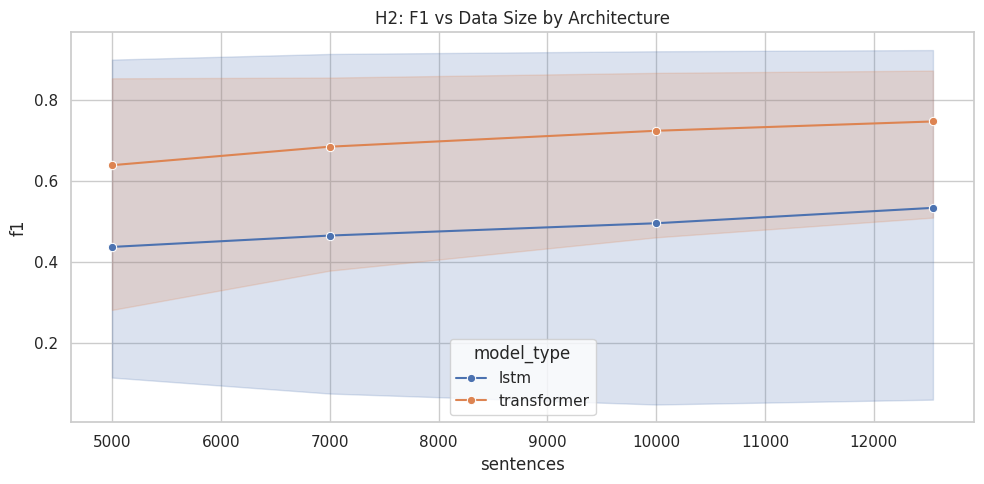

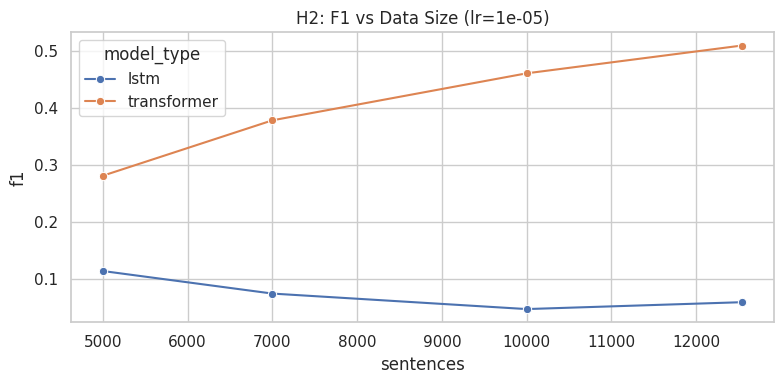

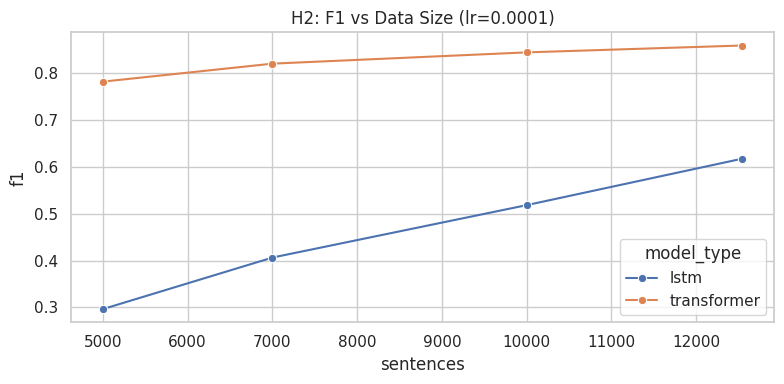

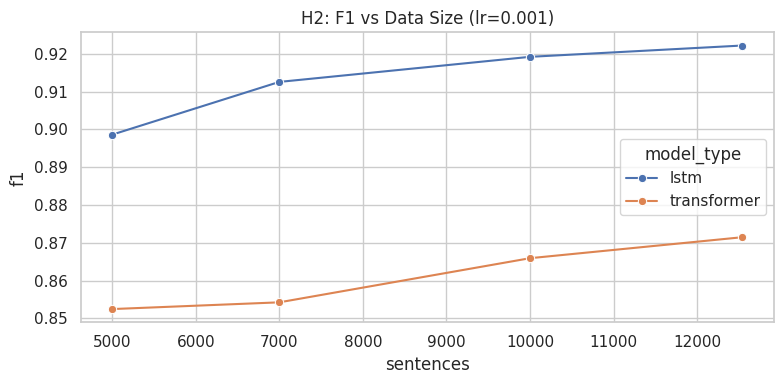

In [52]:
if not h2_data.empty:
    plot_line(
        h2_data,
        x="sentences",
        y=SELECTION_METRIC,
        hue="model_type",
        title=f"H2: {SELECTION_METRIC.upper()} vs Data Size by Architecture",
        figsize=(10, 5)
    )

    # Show for each learning rate separately
    for lr in sorted(h2_data["cfg_lr"].unique()):
        subset = h2_data[h2_data["cfg_lr"] == lr]
        if len(subset) > 0:
            plot_line(
                subset,
                x="sentences",
                y=SELECTION_METRIC,
                hue="model_type",
                title=f"H2: {SELECTION_METRIC.upper()} vs Data Size (lr={lr})",
                figsize=(8, 4)
            )

### Final tables

In [70]:
if not h2_data.empty:
    # Summary by model type and learning rate
    display(Markdown("#### By model type and learning rate"))
    lr_summary = grouped_summary(h2_data, by=["model_type", "cfg_lr"], metric=SELECTION_METRIC)
    display(lr_summary)

    # Summary by model type and sentence count
    display(Markdown("#### By model type and sentence count"))
    data_summary = grouped_summary(h2_data, by=["model_type", "sentences"], metric=SELECTION_METRIC)
    display(data_summary)

#### By model type and learning rate

,model_type,cfg_lr,count,mean,std,min,max
0,lstm,0.00100,4,0.913158,0.010492,0.898624,0.922212
1,transformer,0.00100,4,0.861043,0.009175,0.852479,0.871495
2,transformer,0.00010,4,0.825247,0.033589,0.780887,0.857788
3,lstm,0.00010,4,0.459355,0.138443,0.296588,0.616719
4,transformer,0.00001,4,0.406980,0.099837,0.281044,0.508822
5,lstm,0.00001,4,0.074045,0.028962,0.047616,0.114174


#### By model type and sentence count

,model_type,sentences,count,mean,std,min,max
0,transformer,12543,3,0.746035,0.205547,0.508822,0.871495
1,transformer,10000,3,0.723079,0.227996,0.460141,0.865938
2,transformer,7000,3,0.683777,0.265465,0.377916,0.854261
3,transformer,5000,3,0.638137,0.311316,0.281044,0.852479
4,lstm,12543,3,0.532863,0.437349,0.059658,0.922212
5,lstm,10000,3,0.494898,0.436254,0.047616,0.919217
6,lstm,7000,3,0.464522,0.421952,0.074733,0.912580
7,lstm,5000,3,0.436462,0.410504,0.114174,0.898624


# Hypothesis 3 — Large-Scale Data Scaling

**Hypothesis**  
With a fixed optimal learning rate, performance continues to improve with larger datasets, and transformers scale better than LSTMs.

**Controlled factors**
- Fixed learning rate at optimal value (0.001 for LSTM and 0.00001 for Transformer)
- Brown corpus dataset
- Larger data sizes: 10k, 20k, 30k, max sentences
- Medium/stronger architectures for fair comparison

**What to look for**
- Does performance continue to improve with 20k+ sentences?
- Do transformers scale better than LSTMs with more data?
- Where does performance plateau?

In [67]:
# Filter data for Hypothesis 3
h3_data = get_hypothesis(df, "H3_fixed_lr_more_sents")

if h3_data.empty:
    print("No H3 data found yet. Run experiments with hypothesis='H3_fixed_lr_more_sents' in config.")
else:
    print(f"Found {len(h3_data)} runs for Hypothesis 3")
    display(Markdown("### Hypothesis 3 — All runs"))
    display_cols = [
        "name", "model_type", "sentences", "cfg_lr",
        "f1", "token_accuracy", "best_val_accuracy",
        "train_time_sec", "num_params"
    ]
    display_cols = [c for c in display_cols if c in h3_data.columns]
    display(h3_data[display_cols].sort_values(["sentences", "model_type"]).reset_index(drop=True))

Found 8 runs for Hypothesis 3


### Hypothesis 3 — All runs

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params
0,A_lstm_stronger_s10000,lstm,10000,0.0001,0.743943,0.777145,0.778202,59.325732,3014522
1,A_transformer_medium_s10000,transformer,10000,0.0001,0.875184,0.876861,0.925958,17.254107,3135610
2,A_lstm_stronger_s20000,lstm,20000,0.0001,0.902367,0.910620,0.909151,115.568987,4232966
3,A_transformer_medium_s20000,transformer,20000,0.0001,0.894341,0.895289,0.935448,17.109335,4352518
4,A_lstm_stronger_s30000,lstm,30000,0.0001,0.937449,0.940275,0.939445,173.592195,5132552
5,A_transformer_medium_s30000,transformer,30000,0.0001,0.909366,0.910855,0.943188,23.655699,5251848
6,A_lstm_stronger_smax,lstm,57340,0.0001,0.953639,0.954689,0.955688,1154.073946,6686518
7,A_transformer_medium_smax,transformer,57340,0.0001,0.917934,0.919233,0.951862,42.531069,6799926


### Interpretation

**Expected outcomes:**
1. **Scaling behavior**:
   - Both models should improve with more data
   - Transformers expected to scale better (larger gains from 10k→30k)
   - LSTM gains may plateau earlier

2. **Brown corpus characteristics**:
   - Different tagset than UD
   - May have different difficulty profile
   
3. **Fixed optimal LR**:
   - Using 0.0001 (optimal from H1/H2)
   - Fair comparison of scaling without LR confound

### Visualization: Scaling Performance

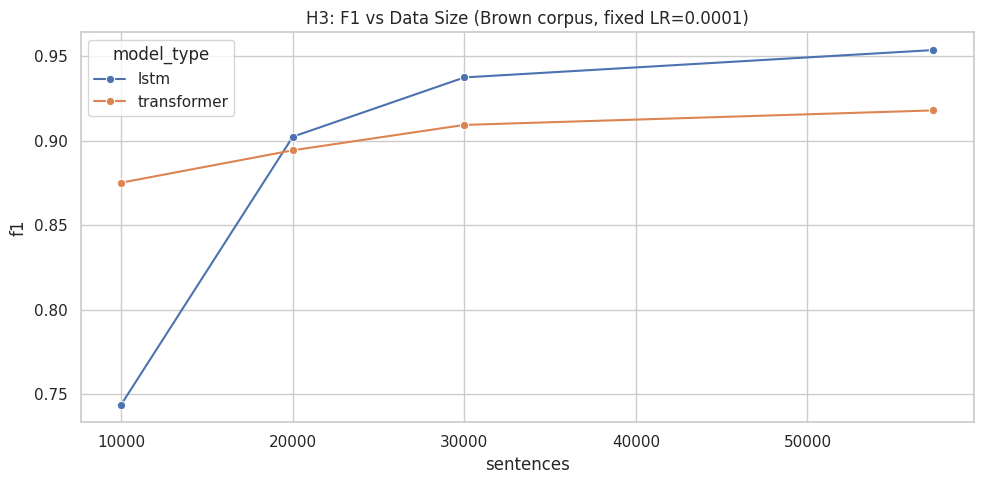

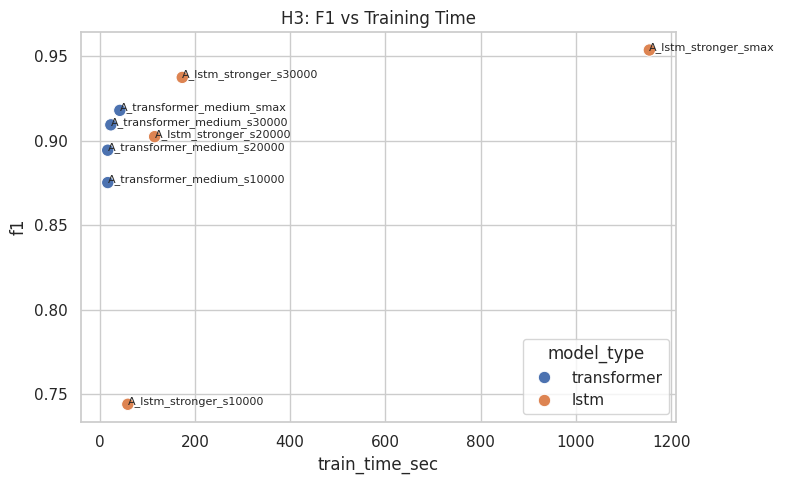

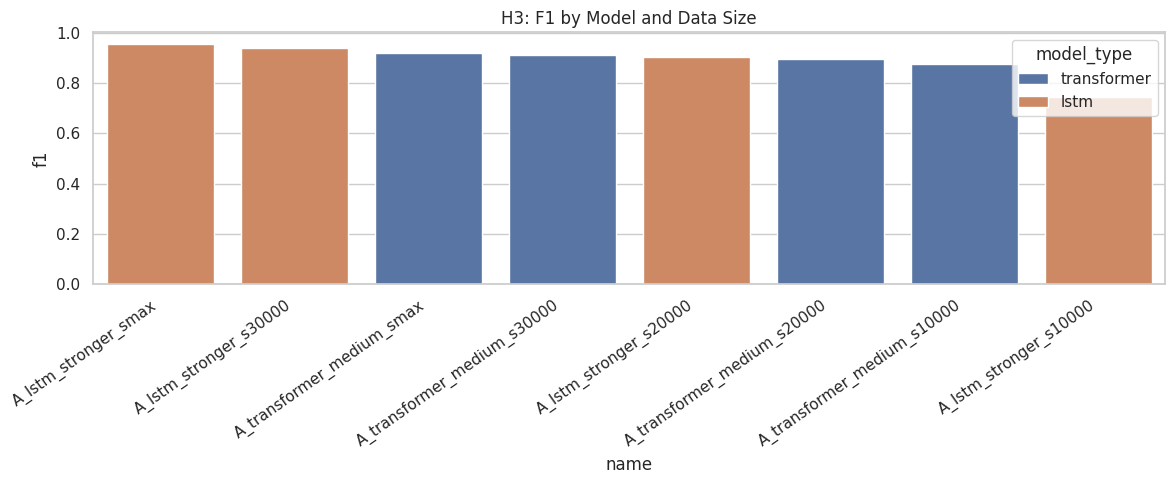

In [68]:
if not h3_data.empty:
    # Main scaling plot
    plot_line(
        h3_data,
        x="sentences",
        y=SELECTION_METRIC,
        hue="model_type",
        title=f"H3: {SELECTION_METRIC.upper()} vs Data Size (Brown corpus, fixed LR=0.0001)",
        figsize=(10, 5)
    )
    
    # Performance vs training time
    annotate_scatter(
        h3_data,
        x="train_time_sec",
        y=SELECTION_METRIC,
        title=f"H3: {SELECTION_METRIC.upper()} vs Training Time",
        figsize=(8, 5)
    )
    
    # Bar plot for direct comparison
    plot_bar(
        h3_data,
        metric=SELECTION_METRIC,
        title=f"H3: {SELECTION_METRIC.upper()} by Model and Data Size",
        hue="model_type",
        figsize=(12, 5)
    )

### Final tables

In [69]:
if not h3_data.empty:
    # Summary by model type and sentence count
    display(Markdown("#### By model type and sentence count"))
    data_summary = grouped_summary(h3_data, by=["model_type", "sentences"], metric=SELECTION_METRIC)
    display(data_summary)
    
    # Scaling efficiency
    display(Markdown("#### Scaling Efficiency"))
    scaling_eff = h3_data.groupby("model_type").agg({
        SELECTION_METRIC: ["mean", "std", "min", "max"],
        "train_time_sec": "mean",
        "num_params": "mean"
    }).reset_index()
    display(scaling_eff)
    
    # Calculate improvement from smallest to largest dataset
    display(Markdown("#### Performance Improvement (10k → max)"))
    for mt in h3_data["model_type"].unique():
        mt_data = h3_data[h3_data["model_type"] == mt].sort_values("sentences")
        if len(mt_data) >= 2:
            first_perf = mt_data.iloc[0][SELECTION_METRIC]
            last_perf = mt_data.iloc[-1][SELECTION_METRIC]
            improvement = last_perf - first_perf
            pct_improvement = (improvement / first_perf) * 100
            print(f"{mt}: {first_perf:.4f} → {last_perf:.4f} (+{improvement:.4f}, +{pct_improvement:.2f}%)")

#### By model type and sentence count

,model_type,sentences,count,mean,std,min,max
0,lstm,57340,1,0.953639,NaN,0.953639,0.953639
1,lstm,30000,1,0.937449,NaN,0.937449,0.937449
2,transformer,57340,1,0.917934,NaN,0.917934,0.917934
3,transformer,30000,1,0.909366,NaN,0.909366,0.909366
4,lstm,20000,1,0.902367,NaN,0.902367,0.902367
5,transformer,20000,1,0.894341,NaN,0.894341,0.894341
6,transformer,10000,1,0.875184,NaN,0.875184,0.875184
7,lstm,10000,1,0.743943,NaN,0.743943,0.743943


#### Scaling Efficiency

model_type        f1                               train_time_sec num_params
                    mean       std       min       max           mean       mean
0         lstm  0.884349  0.096019  0.743943  0.953639     375.640215  4766639.5
1  transformer  0.899206  0.018750  0.875184  0.917934      25.137553  4884975.5

#### Performance Improvement (10k → max)

transformer: 0.8752 → 0.9179 (+0.0427, +4.88%)
lstm: 0.7439 → 0.9536 (+0.2097, +28.19%)
